<a href="https://colab.research.google.com/github/cu24250216-oss/Computer-Vision-Experiments/blob/main/Tanishasingh_60_experiment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EXPERIMENT 04**

**Frequency Domain Image Filtering using Fourier Transform**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-02 092247.png to Screenshot 2026-09-02 092247.png


Image loaded successfully!
Image shape: (295, 510)


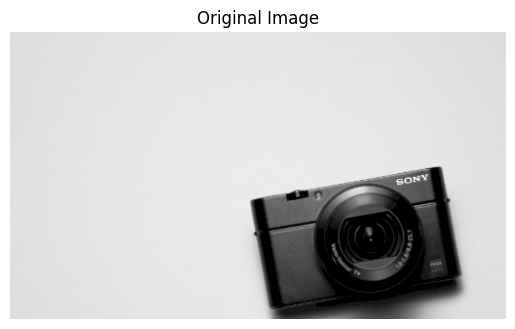

In [6]:
import cv2
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image not found!")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)

    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

In [8]:
dft = cv2.dft(
    np.float32(image),
    flags=cv2.DFT_COMPLEX_OUTPUT
)

dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = cv2.magnitude(
    dft_shift[:, :, 0],
    dft_shift[:, :, 1]
)

magnitude_spectrum = 20 * np.log(
    magnitude_spectrum + 1
)

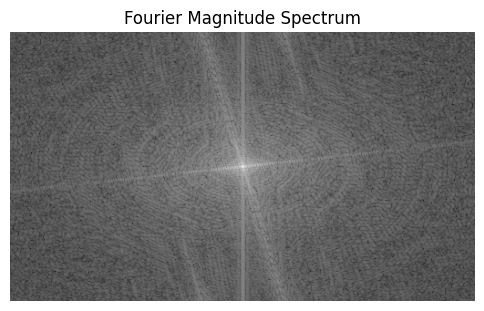

In [9]:
plt.figure(figsize=(6, 6))

plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.show()

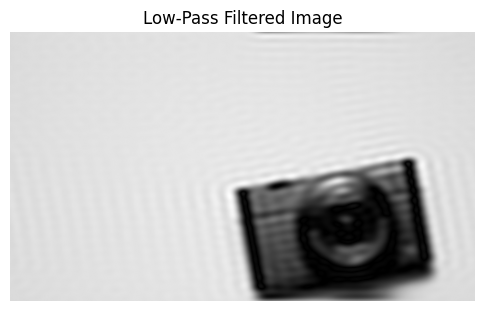

Low-Pass Filtering completed!


In [16]:
# Low-Pass Filter

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

radius = 30

mask_low = np.zeros((rows, cols, 2), np.uint8)

cv2.circle(
    mask_low,
    (ccol, crow),
    radius,
    (1, 1),
    -1
)

# Apply filter
low_pass_dft = dft_shift * mask_low

# Inverse DFT
low_pass_dft = np.fft.ifftshift(low_pass_dft)

low_pass_image = cv2.idft(low_pass_dft)

low_pass_image = cv2.magnitude(
    low_pass_image[:, :, 0],
    low_pass_image[:, :, 1]
)

# Normalize
low_pass_image = cv2.normalize(
    low_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

low_pass_image = np.uint8(low_pass_image)

# SHOW OUTPUT
plt.figure(figsize=(6, 6))
plt.imshow(low_pass_image, cmap="gray")
plt.title("Low-Pass Filtered Image")
plt.axis("off")
plt.show()

print("Low-Pass Filtering completed!")

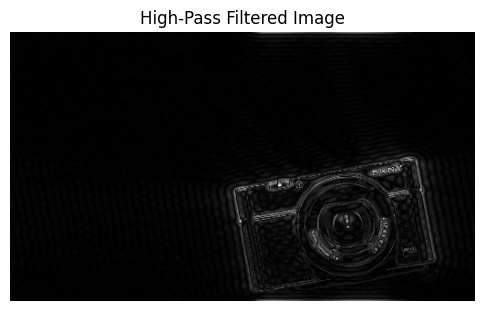

High-Pass Filtering completed!


In [17]:
# High-Pass Filter

mask_high = np.ones((rows, cols, 2), np.uint8)

cv2.circle(
    mask_high,
    (ccol, crow),
    radius,
    (0, 0),
    -1
)

# Apply filter
high_pass_dft = dft_shift * mask_high

# Inverse DFT
high_pass_dft = np.fft.ifftshift(high_pass_dft)

high_pass_image = cv2.idft(high_pass_dft)

high_pass_image = cv2.magnitude(
    high_pass_image[:, :, 0],
    high_pass_image[:, :, 1]
)

# Normalize
high_pass_image = cv2.normalize(
    high_pass_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

high_pass_image = np.uint8(high_pass_image)

# SHOW OUTPUT
plt.figure(figsize=(6, 6))
plt.imshow(high_pass_image, cmap="gray")
plt.title("High-Pass Filtered Image")
plt.axis("off")
plt.show()

print("High-Pass Filtering completed!")

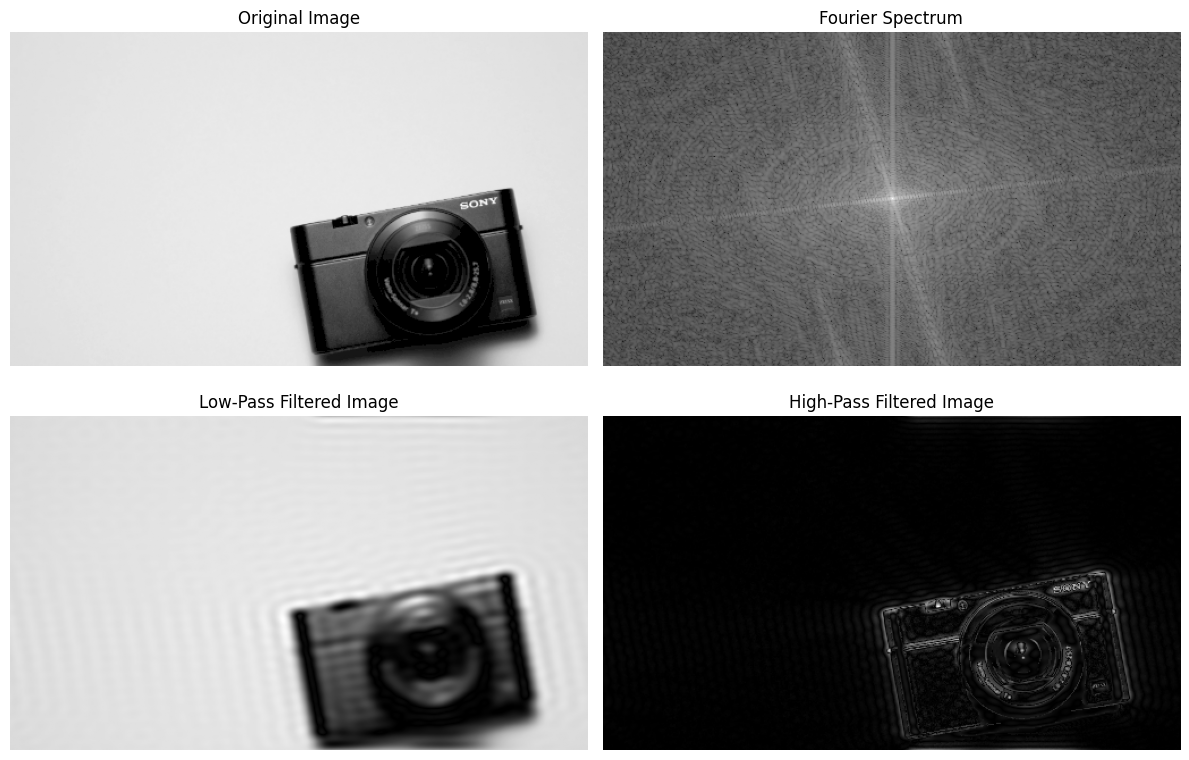

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Fourier Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(low_pass_image, cmap="gray")
plt.title("Low-Pass Filtered Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(high_pass_image, cmap="gray")
plt.title("High-Pass Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

**Questions**

**Q1. What is Fourier Transform? Why is it important in digital image processing?**
**Ans:** Fourier Transform converts an image from spatial domain to frequency domain. It is useful for filtering, noise removal, and sharpening.

**Q2. Differentiate between spatial domain and frequency domain.**
**Ans:**Spatial domain works directly on pixels, while frequency domain works on frequency components of an image.

**Q3. What is the significance of DFT in image processing?**
**Ans**: DFT converts an image into its frequency components, allowing different frequencies to be analyzed and filtered.

**Q4. Why is the zero-frequency component shifted to the center?**
**Ans:** It makes the frequency spectrum easier to visualize, with low frequencies at the center.

**Q5. Compare Low-Pass and High-Pass Frequency Filters.**
**Ans:** Low-pass filters keep low frequencies and smooth the image. High-pass filters keep high frequencies and enhance edges.

**Q6. What is the role of Inverse Fourier Transform?**
**Ans:** It converts the filtered frequency-domain image back into the spatial domain.

**Q7. Why is frequency-domain filtering preferred for certain image enhancement tasks?**
**Ans:** It provides better control over frequency components and is useful for smoothing, sharpening, and noise removal.

**Q8. Why is frequency-domain filtering preferred for certain image enhancement tasks?**
**Ans:** It provides better control over frequency components and is useful for smoothing, sharpening, and noise removal.

**Q9. Compare frequency-domain filtering with spatial-domain filtering.**
**Ans:** Spatial filtering modifies pixels directly, while frequency filtering modifies frequency components using Fourier Transform.

**Q10. How do low-pass and high-pass filtering help image restoration and feature extraction?**
**Ans:** Low-pass filtering reduces noise and smooths images, while high-pass filtering enhances edges and fine details.